In [1]:
import os, sys
import pandas as pd
import numpy as np
import scipy.sparse as sp
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import cv2

import torch
import torch_geometric

from inferenceWithHybridGNet import getDenseMask
from models.HybridGNet2IGSC import Hybrid
from utils.utils import scipy_to_torch_sparse, genMatrixesLungsHeart

HG_ROOT = "/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/models/hybridgnet"
os.chdir(HG_ROOT)
sys.path.insert(0, HG_ROOT) 

print("PyTorch 버전:", torch.__version__)
print("CUDA 사용 가능 여부:", torch.cuda.is_available())
print("CUDA 버전:", torch.version.cuda)

print("PyG 버전:", torch_geometric.__version__)

PyTorch 버전: 2.12.0+cu126
CUDA 사용 가능 여부: True
CUDA 버전: 12.6
PyG 버전: 2.3.1


In [2]:
device = "cuda:0"

A, AD, D, U = genMatrixesLungsHeart()
N1, N2 = A.shape[0], AD.shape[0]
A, AD, D, U = [sp.csc_matrix(M).tocoo() for M in (A, AD, D, U)]

config = {
    "n_nodes": [N1, N1, N1, N2, N2, N2],
    "latents": 64,
    "inputsize": 1024,
}
f = 32
config["filters"] = [2, f, f, f, f//2, f//2, f//2]
config["skip_features"] = f

A_ = [A.copy(), A.copy(), A.copy(), AD.copy(), AD.copy(), AD.copy()]
A_t = [scipy_to_torch_sparse(x).to(device) for x in A_]
D_t = [scipy_to_torch_sparse(D.copy()).to(device)]
U_t = [scipy_to_torch_sparse(U.copy()).to(device)]

hybrid = Hybrid(config.copy(), D_t, U_t, A_t).to(device)
hybrid.load_state_dict(torch.load("./Weights/SegmentationModel/bestMSE.pt", map_location=device, weights_only=True))
hybrid.eval()
print("Model loaded")

/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/models/hybridgnet/utils/utils.py:56: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:654.)
  sparse_tensor = torch.sparse.FloatTensor(i, v, torch.Size(shape))


Model loaded


In [3]:
# IMG_PATH = "/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/icu_cxr/mimic-cxr-jpg/2.1.0/files/p14/p14000990/s53956867/422b7dd8-482dbbfd-2dffdfd8-8f686c68-924d3ec8.jpg"

# img_raw = cv2.imread(IMG_PATH, 0)
# H0, W0 = img_raw.shape
# img = cv2.resize(img_raw, (1024, 1024)).astype(np.float32) / 255.0
# data = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).to(device)

# with torch.no_grad():
#     output = hybrid(data)
#     if len(output) > 1:
#         output = output[0]
# output = output.cpu().numpy().reshape(-1, 2) * 1024
# output = output.round().astype("int")

# RL, LL, Hp = output[:44], output[44:94], output[94:]

# mask_1024 = getDenseMask(RL, LL, Hp)                       # 0=bg, 1=lungs, 2=heart
# mask = cv2.resize(mask_1024, (W0, H0), interpolation=cv2.INTER_NEAREST)

# sx, sy = W0 / 1024.0, H0 / 1024.0
# RL_o = (RL * [sx, sy]).astype(int)
# LL_o = (LL * [sx, sy]).astype(int)
# H_o  = (Hp * [sx, sy]).astype(int)

# fig, ax = plt.subplots(1, 3, figsize=(15, 5))
# ax[0].imshow(img_raw, cmap="gray"); ax[0].set_title("Input"); ax[0].axis("off")
# ax[1].imshow(mask, cmap="viridis"); ax[1].set_title("Mask (1=lung,2=heart)"); ax[1].axis("off")
# ax[2].imshow(img_raw, cmap="gray")
# ax[2].plot(*RL_o.T, "r-", lw=1.2); ax[2].plot(*LL_o.T, "g-", lw=1.2); ax[2].plot(*H_o.T, "b-", lw=1.2)
# ax[2].set_title("Overlay"); ax[2].axis("off")
# plt.tight_layout(); plt.show()

## Inference mode에서 lung, heart embedding 뽑기

In [4]:
existing_df = pd.read_feather('/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/final_cxr_df_in_icu_20260511.ftr')

In [5]:
root_dir = '/home/DAHS1/mimic-cxr-jpg-2.0.0'

# vp_extract_df = pd.read_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/final_cxr_df_20260504.ftr")
# filtered = vp_extract_df[vp_extract_df['ViewPosition'].isin(['AP', 'PA'])]

# image_paths = [os.path.join(root_dir, p) for p in filtered['image_path']]
# filtered['full_path'] = filtered['image_path'].apply(lambda p: os.path.join(root_dir, p))

# frontal_image_paths = filtered['full_path'].tolist()
# print(f"총 {len(frontal_image_paths)}개의 Frontal View 이미지 파일")

cohort_image_paths = existing_df['image_path'].dropna().unique().tolist()
all_image_paths = [os.path.join(root_dir, path) for path in cohort_image_paths]

# label
label_csv = pd.read_csv('/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/mimic-cxr-2.0.0-chexpert.csv.gz', compression='gzip')

In [6]:
len(all_image_paths)

53228

In [7]:
all_image_paths[0]

'/home/DAHS1/mimic-cxr-jpg-2.0.0/files/p10/p10001884/s57156853/9fd47edd-07087209-b901811e-3e9e5f50-f382f611.jpg'

In [8]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

embed_save_root = '/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/hybridgnet_embeddings'
vis_save_root = '/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/hybridgnet_visuals'

os.makedirs(embed_save_root, exist_ok=True)
os.makedirs(vis_save_root, exist_ok=True)

cuda:0


In [9]:
A, AD, D, U = genMatrixesLungsHeart()
A, AD, D, U = [sp.csc_matrix(M).tocoo() for M in (A, AD, D, U)]

A_ = [A.copy(), A.copy(), A.copy(), AD.copy(), AD.copy(), AD.copy()]
A_t = [scipy_to_torch_sparse(x).to(device) for x in A_]
D_t = [scipy_to_torch_sparse(D.copy()).to(device)]
U_t = [scipy_to_torch_sparse(U.copy()).to(device)]

config = {'n_nodes': [A.shape[0]]*3 + [AD.shape[0]]*3, 'latents': 64, 'inputsize': 1024, 'filters': [2, 32, 32, 32, 16, 16, 16]}
hybrid = Hybrid(config, D_t, U_t, A_t).to(device)
hybrid.load_state_dict(torch.load("./Weights/SegmentationModel/bestMSE.pt", map_location=device, weights_only=True))
hybrid.eval()

Hybrid(
  (encoder): EncoderConv(
    (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (dconv_down1): residualBlock(
      (skip): Sequential(
        (0): Conv2d(1, 8, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=False)
      )
      (block): Sequential(
        (0): BatchNorm2d(1, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=False)
        (1): ReLU(inplace=True)
        (2): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=False)
        (4): ReLU(inplace=True)
        (5): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (dconv_down2): residualBlock(
      (skip): Sequential(
        (0): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(16, e

In [10]:
SAVE_VISUALS = False
test_for_visual = all_image_paths[:50]

심흉곽비 (CTR) = 심장의 최대 횡경/흉곽의 최대 횡경

- 심장의 최대 횡경: 척추 중심선에서 가장 많이 튀어나온 심장의 우측 끝까지의 거리와, 좌측 끝까지의 거리를 합산함.
- 흉곽의 최대 횡경: 양측 갈비뼈(늑골) 안쪽의 가장 넓은 내부 가로 길이.

In [11]:
label_csv

,subject_id,study_id,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
0,10000032,50414267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,10000032,53189527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
2,10000032,53911762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
3,10000032,56699142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
4,10000764,57375967,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227822,19999442,58708861,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0
227823,19999733,57132437,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
227824,19999987,55368167,1.0,-1.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN
227825,19999987,58621812,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [12]:
label_csv['Cardiomegaly'].value_counts()

Cardiomegaly
 1.0    44845
 0.0    15911
-1.0     6043
Name: count, dtype: int64

In [13]:
sample_img_path = all_image_paths[6]
print(f"Testing image: {sample_img_path}")

# --- 라벨 조회 ---
path_parts = sample_img_path.split('/')
subject_id = int(path_parts[-3][1:])
study_id   = int(path_parts[-2][1:])

row = label_csv[(label_csv['subject_id'] == subject_id) &
                (label_csv['study_id']   == study_id)]

print(f"subject_id: {subject_id}, study_id: {study_id}")
cardiomegaly_label = row['Cardiomegaly'].iloc[0]
label_meaning = {1.0: "Positive (심비대)", 0.0: "Negative (정상)", -1.0: "Uncertain (불확실)"}
desc = label_meaning.get(cardiomegaly_label, "Not mentioned (NaN)")
print(f"CheXpert Cardiomegaly Label: {cardiomegaly_label} → {desc}")
# -----------------

# 2. 이미지 로드 및 전처리 (기존과 동일)
img_raw = cv2.imread(sample_img_path, 0)
H0, W0 = img_raw.shape
img = cv2.resize(img_raw, (1024, 1024)).astype(np.float32) / 255.0
data = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).to(device)

# 3. 모델 추론
with torch.no_grad():
    coords, node_features, _, _ = hybrid(data)

# 4. 좌표 값 추출
coords_np = coords.squeeze(0).cpu().numpy() # [113, 2]

print("\n" + "="*40)
print("🔍 1. Raw Coordinates Range Check")
print("="*40)
print(f"Shape: {coords_np.shape}")
print(f"X-axis (Min ~ Max): {coords_np[:, 0].min():.4f} ~ {coords_np[:, 0].max():.4f}")
print(f"Y-axis (Min ~ Max): {coords_np[:, 1].min():.4f} ~ {coords_np[:, 1].max():.4f}")
print(f"Sample points (First 3 nodes):\n{coords_np[:3]}")

# 5. 우리가 설계한 기하학(Geometry) 공식 테스트
lung_coords = coords_np[:94]   # 폐 노드 94개
heart_coords = coords_np[94:]  # 심장 노드 19개

heart_width = heart_coords[:, 0].max() - heart_coords[:, 0].min()
thoracic_width = lung_coords[:, 0].max() - lung_coords[:, 0].min()
ctr = heart_width / (thoracic_width + 1e-6)
lung_height = lung_coords[:, 1].max() - lung_coords[:, 1].min()

print("\n" + "="*40)
print("🩺 2. Clinical Geometry Check")
print("="*40)
print(f"Heart Width:    {heart_width:.4f}")
print(f"Thoracic Width: {thoracic_width:.4f}")
print(f"Lung Height:    {lung_height:.4f}")
print(f"Calculated CTR: {ctr:.4f} ", end="")

if ctr > 0.5:
    print("(🚨 심비대 의심 구간)")
else:
    print("(✅ 정상 구간)")
print("="*40 + "\n")

Testing image: /home/DAHS1/mimic-cxr-jpg-2.0.0/files/p10/p10002428/s57064083/217e6a56-b4a78227-a2acc34d-3b571d4a-27b9746a.jpg
subject_id: 10002428, study_id: 57064083
CheXpert Cardiomegaly Label: 0.0 → Negative (정상)

🔍 1. Raw Coordinates Range Check
Shape: (120, 2)
X-axis (Min ~ Max): 0.0960 ~ 0.9019
Y-axis (Min ~ Max): -0.0001 ~ 0.7276
Sample points (First 3 nodes):
[[ 4.7521275e-01  2.8354556e-03]
 [ 4.4316632e-01 -9.7955257e-05]
 [ 4.0654454e-01  7.2543472e-03]]

🩺 2. Clinical Geometry Check
Heart Width:    0.3846
Thoracic Width: 0.8059
Lung Height:    0.7276
Calculated CTR: 0.4773 (✅ 정상 구간)



/home/DAHS1/anaconda3/envs/backup_05/lib/python3.10/site-packages/torch/nn/modules/module.py:1789: UserWarning: input's size at dim=1 does not match num_features. You can silence this warning by not passing in num_features, which is not used because affine=False
  return forward_call(*args, **kwargs)


In [14]:
with torch.no_grad():
    for img_path in tqdm(all_image_paths, total=len(all_image_paths), desc="Segmentation Embedding Extraction"):
        path_parts = img_path.split('/')
        file_name_base = "_".join(path_parts[-4:]).replace('.jpg', '')
        pt_save_path = os.path.join(embed_save_root, f"{file_name_base}.pt")
        png_save_path = os.path.join(vis_save_root, f"{file_name_base}_overlay.png")

        if os.path.exists(pt_save_path):
            continue

        img_raw = cv2.imread(img_path, 0)
        if img_raw is None: continue

        H0, W0 = img_raw.shape

        img = cv2.resize(img_raw, (1024, 1024)).astype(np.float32) / 255.0
        data = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).to(device)

        # 모델 추론
        coords, node_features, _, _ = hybrid(data)
        
        # 임베딩 추출 및 저장
        nodes = node_features.squeeze(0) # [Nodes, 32]

        ######################################################################################################
        # 심흉곽비 계산
        coords_np = coords.squeeze(0).cpu().numpy() # [113, 2]
        
        lung_coords = coords_np[:94]   # 우측 폐(44) + 좌측 폐(50)
        heart_coords = coords_np[94:]  # 심장(19)

        # 1. 심장 최대 너비 계산
        heart_width = heart_coords[:, 0].max() - heart_coords[:, 0].min()
        
        # 2. 흉곽 전체 최대 너비 계산
        thoracic_width = lung_coords[:, 0].max() - lung_coords[:, 0].min()
        
        # 3. 심흉곽비 (CTR) - 분모 0 방지
        ctr = heart_width / (thoracic_width + 1e-6)

        # 기하학 텐서 생성 [4차원]
        geom_features = torch.tensor([ctr, heart_width, thoracic_width], dtype=torch.float32)
        ######################################################################################################
        embedding_payload = {
            "r_lung": nodes[:44, :].mean(dim=0).cpu(),
            "l_lung": nodes[44:94, :].mean(dim=0).cpu(),
            "heart": nodes[94:, :].mean(dim=0).cpu(),
            "lung": nodes[:94, :].mean(dim=0).cpu(),
            "geometry": geom_features, # 추가
            "path": img_path
        }
        torch.save(embedding_payload, pt_save_path)
        
        # if SAVE_VISUALS:
        #     coords_np = coords.cpu().numpy().reshape(-1, 2) * 1024
        #     coords_np = coords_np.round().astype('int')
            
        #     RL, LL, Hp = coords_np[:44], coords_np[44:94], coords_np[94:]
            
        #     mask_1024 = getDenseMask(RL, LL, Hp)
            
        #     mask = cv2.resize(mask_1024, (W0, H0), interpolation=cv2.INTER_NEAREST)
            
        #     img_color = cv2.cvtColor(img_raw, cv2.COLOR_GRAY2BGR)
            
        #     overlay = img_color.copy()
        #     overlay[mask == 1] = [0, 255, 0]   # 폐 (BGR 기준 Green)
        #     overlay[mask == 2] = [0, 0, 255]   # 심장 (BGR 기준 Red)
            
        #     alpha = 0.3
        #     blended = cv2.addWeighted(overlay, alpha, img_color, 1 - alpha, 0)
            
        #     cv2.imwrite(png_save_path, blended)

Segmentation Embedding Extraction:   0%|          | 0/53228 [00:00<?, ?it/s]

In [15]:
import glob
from collections import defaultdict

# 1. 저장된 임베딩에서 (subject_id, study_id, ctr) 수집
pt_files = glob.glob(os.path.join(embed_save_root, "*.pt"))
print(f"임베딩 파일 수: {len(pt_files)}")

records = []
for pt_path in tqdm(pt_files, desc="Loading CTRs"):
    payload = torch.load(pt_path, map_location="cpu", weights_only=False)
    img_path = payload["path"]
    parts = img_path.split('/')
    subject_id = int(parts[-3][1:])
    study_id   = int(parts[-2][1:])
    ctr = float(payload["geometry"][0])  # [ctr, heart_w, thoracic_w, lung_h]
    records.append((subject_id, study_id, ctr))

ctr_df = pd.DataFrame(records, columns=["subject_id", "study_id", "ctr"])
print(f"CTR records: {len(ctr_df)}")

# 2. 라벨과 조인 (study 단위)
merged = ctr_df.merge(
    label_csv[["subject_id", "study_id", "Cardiomegaly"]],
    on=["subject_id", "study_id"],
    how="left",
)
print("\nCardiomegaly 라벨 분포 (조인 후):")
print(merged["Cardiomegaly"].value_counts(dropna=False))

# 3. 라벨별 CTR 통계 + Threshold(0.5) 일치율
THRESHOLD = 0.5
print("\n" + "="*60)
print(f"📊 CTR vs CheXpert Cardiomegaly  (threshold = {THRESHOLD})")
print("="*60)

for label_val, name in [(0.0, "Negative (정상)"),
                        (1.0, "Positive (심비대)"),
                        (-1.0, "Uncertain"),
                        (np.nan, "Not mentioned")]:
    if pd.isna(label_val):
        sub = merged[merged["Cardiomegaly"].isna()]
    else:
        sub = merged[merged["Cardiomegaly"] == label_val]
    n = len(sub)
    if n == 0:
        print(f"\n[{name}]  N=0  (없음)")
        continue
    below = (sub["ctr"] < THRESHOLD).sum()
    above = (sub["ctr"] >= THRESHOLD).sum()
    print(f"\n[{name}]  N = {n}")
    print(f"  CTR  < {THRESHOLD}: {below:>6d} ({below/n*100:5.2f}%)")
    print(f"  CTR >= {THRESHOLD}: {above:>6d} ({above/n*100:5.2f}%)")
    print(f"  CTR mean={sub['ctr'].mean():.4f}, median={sub['ctr'].median():.4f}, "
          f"std={sub['ctr'].std():.4f}, min={sub['ctr'].min():.4f}, max={sub['ctr'].max():.4f}")

# 4. 핵심 두 가지 비율 요약
neg = merged[merged["Cardiomegaly"] == 0.0]
pos = merged[merged["Cardiomegaly"] == 1.0]
neg_correct = (neg["ctr"] < THRESHOLD).mean() if len(neg) else float("nan")
pos_correct = (pos["ctr"] >= THRESHOLD).mean() if len(pos) else float("nan")

print("\n" + "="*60)
print("✅ 요약")
print("="*60)
print(f"  Label=0.0 (정상) 중 CTR < 0.5  : {neg_correct*100:.2f}%  (specificity-유사)")
print(f"  Label=1.0 (심비대) 중 CTR ≥ 0.5: {pos_correct*100:.2f}%  (sensitivity-유사)")


임베딩 파일 수: 53228


Loading CTRs:   0%|          | 0/53228 [00:00<?, ?it/s]

CTR records: 53228

Cardiomegaly 라벨 분포 (조인 후):
Cardiomegaly
 NaN    29647
 1.0    17019
 0.0     4159
-1.0     2403
Name: count, dtype: int64

📊 CTR vs CheXpert Cardiomegaly  (threshold = 0.5)

[Negative (정상)]  N = 4159
  CTR  < 0.5:   1848 (44.43%)
  CTR >= 0.5:   2311 (55.57%)
  CTR mean=0.5098, median=0.5073, std=0.0550, min=0.2113, max=0.8021

[Positive (심비대)]  N = 17019
  CTR  < 0.5:   2092 (12.29%)
  CTR >= 0.5:  14927 (87.71%)
  CTR mean=0.5657, median=0.5675, std=0.0595, min=0.2121, max=0.8025

[Uncertain]  N = 2403
  CTR  < 0.5:    532 (22.14%)
  CTR >= 0.5:   1871 (77.86%)
  CTR mean=0.5439, median=0.5452, std=0.0588, min=0.2890, max=0.7719

[Not mentioned]  N = 29647
  CTR  < 0.5:   7351 (24.80%)
  CTR >= 0.5:  22296 (75.20%)
  CTR mean=0.5409, median=0.5420, std=0.0636, min=0.2159, max=0.8637

✅ 요약
  Label=0.0 (정상) 중 CTR < 0.5  : 44.43%  (specificity-유사)
  Label=1.0 (심비대) 중 CTR ≥ 0.5: 87.71%  (sensitivity-유사)


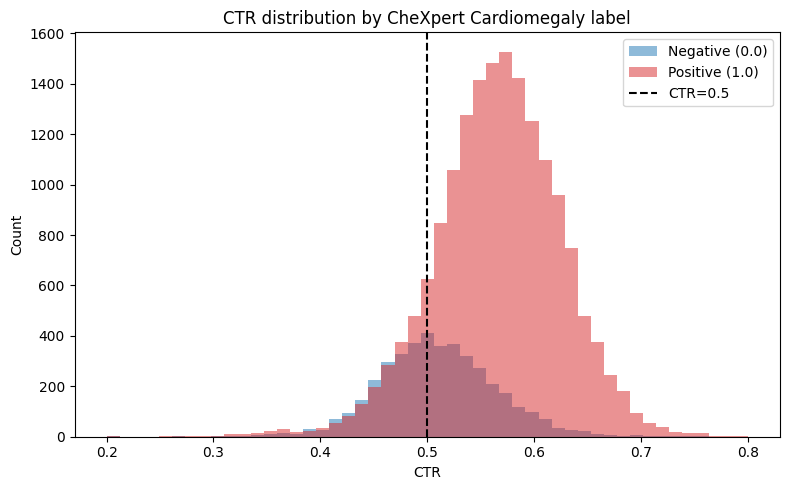

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(0.2, 0.8, 50)
ax.hist(merged.loc[merged["Cardiomegaly"] == 0.0, "ctr"], bins=bins,
        alpha=0.5, label="Negative (0.0)", color="tab:blue")
ax.hist(merged.loc[merged["Cardiomegaly"] == 1.0, "ctr"], bins=bins,
        alpha=0.5, label="Positive (1.0)", color="tab:red")
ax.axvline(0.5, color="k", linestyle="--", label="CTR=0.5")
ax.set_xlabel("CTR"); ax.set_ylabel("Count")
ax.set_title("CTR distribution by CheXpert Cardiomegaly label")
ax.legend(); plt.tight_layout(); plt.show()
